In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.append('..')
import sourse
import os
import sourse_new
import matplotlib.patches as patches
plt.rcParams["font.size"] = 14

In [11]:
data_A = np.loadtxt('C:\\Users\\manat\\project2\\surface_wave_2d\\T1\\T1_A.csv')

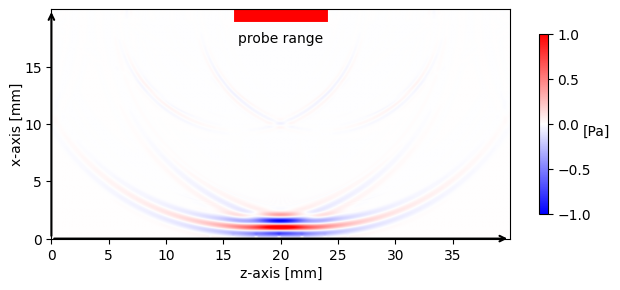

In [12]:
plt.rcParams["font.size"] = 10
# 画像の表示
plt.figure()
plt.imshow(np.flipud(data_A), cmap="bwr", vmin=-1, vmax=1, origin='lower')  # データを上下反転してから表示
im=plt.imshow(np.flipud(data_A), cmap="bwr", vmin=-1, vmax=1, origin='lower')
cbar = plt.colorbar(im, shrink=0.4, label="[Pa]")
cbar.set_label('[Pa]', rotation=0)
plt.xticks(np.arange(0,4000,500),np.arange(0,40,5))
plt.yticks(np.arange(0,2000,500),np.arange(0,20,5))

# x軸方向の矢印（右向き）
plt.annotate("", xy=(4000, 0), xytext=(0, 0), 
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5))

# y軸方向の矢印（上向き）
plt.annotate("", xy=(0, 2000), xytext=(0, 0), 
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5))

plt.plot([2000-350, 2000+350], [1950, 1950], 'r-', lw=10)
plt.text(2000, 1750, "probe range", va='center', ha='center')

# 下部のx軸を表示
plt.tick_params(axis='x', which='both', bottom=True, labelbottom=True)

# 上部にx軸を非表示
plt.tick_params(axis='x', which='both', top=False, labeltop=False)

# 軸ラベルの追加
plt.text(-300, 1000, "x-axis [mm]", rotation=90, va='center', ha='center')
plt.text(2000, -300, "z-axis [mm]", va='center', ha='center')

plt.tight_layout()

plt.savefig("C:\\Users\\manat\\project2\\tmp_output\\Figure4.eps", dpi=300, format="eps")

In [2]:
sim_ref = -np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch125_depth0.csv")
exp_ref = sourse_new.import_data(0, 0)[0]

sim_rough = -np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch150_depth20.csv")
exp_rough = sourse_new.import_data(150, 20)[0]

sim_ref = sourse_new.kiritori2(sourse_new.interpolate_sim_one(sim_ref[9000:]), sourse_new.left, sourse_new.right)
exp_ref = sourse_new.kiritori2(exp_ref, sourse_new.left, sourse_new.right)

sim_rough = sourse_new.kiritori2(sourse_new.interpolate_sim_one(sim_rough[9000:]), sourse_new.left, sourse_new.right)
exp_rough = sourse_new.kiritori2(exp_rough, sourse_new.left, sourse_new.right)

yf_sim_ref, freq = sourse_new.make_fftdata(sim_ref, sourse_new.exp_dt)
yf_exp_ref, freq = sourse_new.make_fftdata(exp_ref, sourse_new.exp_dt)

yf_sim_rough, freq = sourse_new.make_fftdata(sim_rough, sourse_new.exp_dt)
yf_exp_rough, freq = sourse_new.make_fftdata(exp_rough, sourse_new.exp_dt)

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_90.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_91.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_92.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


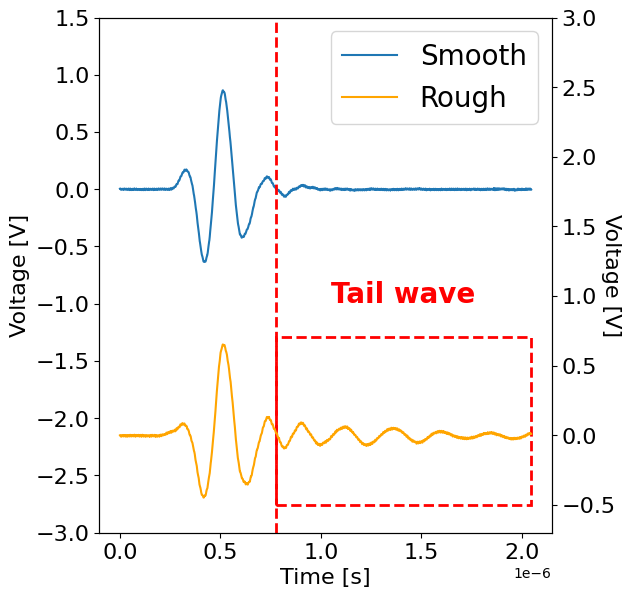

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
# step2 y軸の作成
twin1 = ax.twinx()
t = np.arange(0, sourse_new.exp_dt*len(sim_ref), sourse_new.exp_dt)

p1, = ax.plot(t, exp_ref, label='Smooth')
p2, = twin1.plot(t, exp_rough, label='Rough', color="orange")
# 囲みたい範囲を指定（時間軸の範囲）
highlight_start = 1550*sourse_new.exp_dt  # 開始時間
highlight_end = t[-1]

# 四角形を描画（twin1の軸に合わせる）
rect = patches.Rectangle((highlight_start, twin1.get_ylim()[0]), 
                        highlight_end - highlight_start, 
                        twin1.get_ylim()[1] - twin1.get_ylim()[0],
                        linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
twin1.add_patch(rect)
# 四角形の上に文字を追加
# 左辺を上まで延長する縦線
ax.axvline(x=highlight_start, ymin=0, ymax=1, color='red', linestyle='--', linewidth=2)

text_x = (highlight_start + highlight_end) / 2  # 四角形の中央
text_y = twin1.get_ylim()[1] + 0.2  # 四角形の上端より少し上
twin1.text(text_x, text_y, 'Tail wave', 
           ha='center', va='bottom', fontsize=20, color='red', weight='bold')
fig.tight_layout()
ax.set_ylim(-3.0, 1.5)
twin1.set_ylim(-0.7, 3)
ax.set_xlabel('Time [s]',fontsize=16)
ax.set_ylabel('Voltage [V]',fontsize=16)
twin1.set_ylabel('Voltage [V]', rotation=270, fontsize=16)
# step4 凡例の追加
ax.legend(handles=[p1, p2],fontsize=20)
plt.tight_layout()# 軸の目盛りラベルのフォントサイズを設定
ax.tick_params(axis='both', which='major', labelsize=16)  # 左のy軸と x軸
twin1.tick_params(axis='y', which='major', labelsize=16)  # 右のy軸


plt.savefig(r"C:\Users\manat\project2\drawing\sice\Figure5b.eps", format="eps", dpi=300)
plt.show()



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


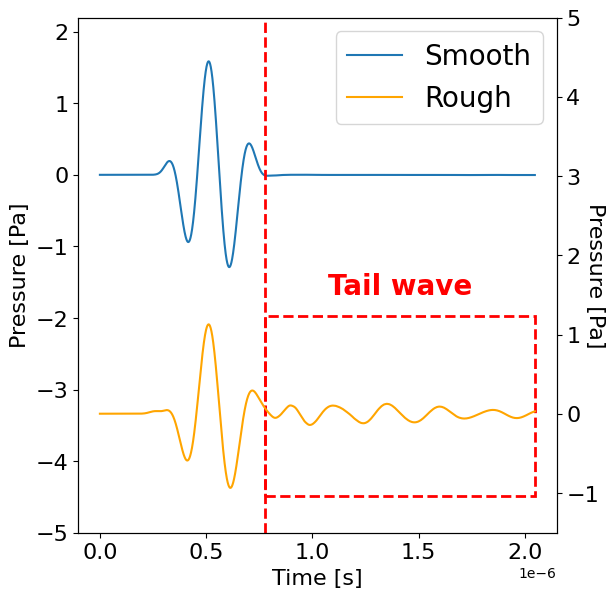

In [15]:
fig, ax = plt.subplots(figsize=(6, 6))
# step2 y軸の作成
twin1 = ax.twinx()
t = np.arange(0, sourse_new.exp_dt*len(sim_ref), sourse_new.exp_dt)

p1, = ax.plot(t, sim_ref, label='Smooth')
p2, = twin1.plot(t, sim_rough, label='Rough', color="orange")

# 囲みたい範囲を指定（時間軸の範囲）
highlight_start = 1550*sourse_new.exp_dt  # 開始時間
highlight_end = t[-1]  # 終了時間

# 四角形を描画（twin1の軸に合わせる）
rect = patches.Rectangle((highlight_start, twin1.get_ylim()[0]), 
                        highlight_end - highlight_start, 
                        twin1.get_ylim()[1] - twin1.get_ylim()[0],
                        linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
twin1.add_patch(rect)
# 四角形の上に文字を追加
# 左辺を上まで延長する縦線
ax.axvline(x=highlight_start, ymin=0, ymax=1, color='red', linestyle='--', linewidth=2)

# 四角形の上に文字を追加
text_x = (highlight_start + highlight_end) / 2  # 四角形の中央
text_y = twin1.get_ylim()[1] + 0.2  # 四角形の上端より少し上
twin1.text(text_x, text_y, 'Tail wave', 
           ha='center', va='bottom', fontsize=20, color='red', weight='bold')
ax.set_ylim(-5.0, 2.2)
twin1.set_ylim(-1.5, 5.0)
ax.set_xlabel('Time [s]', fontsize=16)
ax.set_ylabel('Pressure [Pa]', fontsize=16)
twin1.set_ylabel('Pressure [Pa]', rotation=270, fontsize=16)
# step4 凡例の追加
ax.legend(handles=[p1, p2], fontsize=20)
plt.tight_layout()
# 軸の目盛りラベルのフォントサイズを設定
ax.tick_params(axis='both', which='major', labelsize=16)  # 左のy軸と x軸
twin1.tick_params(axis='y', which='major', labelsize=16)  # 右のy軸

plt.savefig(r"C:\Users\manat\project2\drawing\sice\Figure5a.eps", format="eps", dpi=300)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


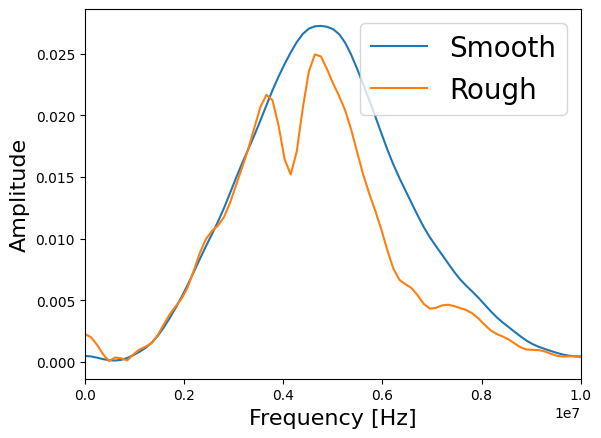

In [16]:
plt.figure()
plt.plot(freq, yf_exp_ref, label="Smooth")
plt.plot(freq, yf_exp_rough, label="Rough")
plt.xlabel("Frequency [Hz]",fontsize=16)
plt.ylabel("Amplitude",fontsize=16)
plt.legend(fontsize=20)
plt.xlim(0, 10e6)

plt.savefig(r"C:\Users\manat\project2\drawing\sice\Figure6a.eps", format="eps", dpi=300)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


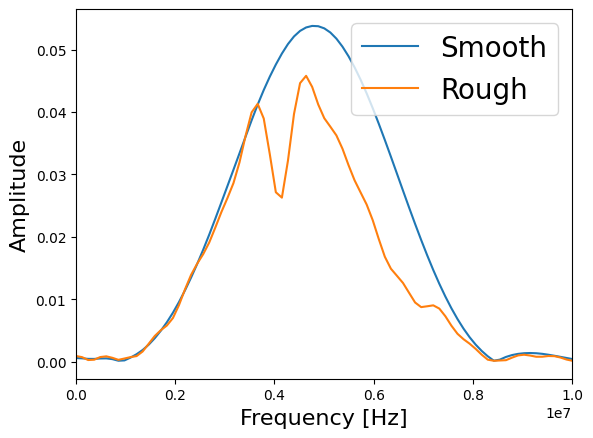

In [17]:
plt.figure()
plt.plot(freq, yf_sim_ref, label="Smooth")
plt.plot(freq, yf_sim_rough, label="Rough")
plt.xlabel("Frequency [Hz]",fontsize=16)
plt.ylabel("Amplitude",fontsize=16)
plt.legend(fontsize=20)
plt.xlim(0, 10e6)

plt.savefig(r"C:\Users\manat\project2\drawing\sice\Figure6b.eps", format="eps", dpi=300)
plt.show()

In [18]:
wave1_20 = sourse_new.import_data(150, 20)[0]
wave2_20 = sourse_new.import_data(175, 21)[0]
yf1_20, freq = sourse_new.make_fftdata_main_tale(sourse_new.kiritori2
                                                   (sourse_new.interpolate_sim_one(-np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch150_depth20.csv")[9000:]), sourse_new.left, sourse_new.right), sourse_new.exp_dt, 1500)
yf2_20, freq = sourse_new.make_fftdata_main_tale(sourse_new.kiritori2
                                                   (sourse_new.interpolate_sim_one(-np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch175_depth20.csv")[9000:]), sourse_new.left, sourse_new.right), sourse_new.exp_dt, 1550)

filename_1_20 = f"C:\\Users\\manat\\project2\\surface_wave_2d\\T3\\T3_series_middle_moremorerange_150_moredepth.npy"
filename_2_20 = f"C:\\Users\\manat\\project2\\surface_wave_2d\\T3\\T3_series_middle_moremorerange_175_moredepth.npy"

importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_90.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_91.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_92.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_93.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_94.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_95.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_96.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_97.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_98.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_99.csv
importing : C:\Users\manat\project2\experience_new\175_21\scope_5b3_120.csv
importing : C:\Users\manat\project2\experience_new\175_21\scope_5b3_121.csv
importing : C:\Users\manat\project2\experience_new\175_21\scope_5b3_122.csv
importing : C:\Users\m

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


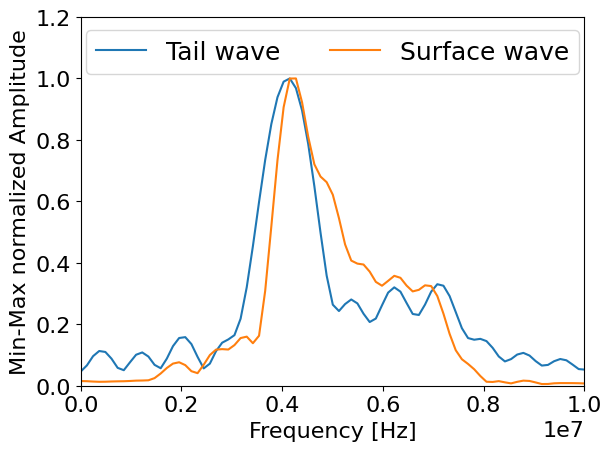

In [19]:
middle_175 = int((1924+2075)/2 - 1850)
middle_150 = int((1949+2074)/2 - 1874)

data1 = np.load(filename_1_20)
data2 = np.load(filename_2_20)

yf_surface_1, freq_surface = sourse_new.make_fftdata(sourse_new.kiritori2(sourse_new.interpolate_sim_one(data1[-1, middle_150, :]), sourse_new.left, sourse_new.right), sourse_new.exp_dt)

plt.rcParams["font.size"] = 16
plt.plot(freq[0], yf1_20[2]/yf1_20[2].max(), label="Tail wave")
plt.plot(freq_surface, yf_surface_1/yf_surface_1.max(), label="Surface wave")

plt.xlim(0, 10000000)
plt.ylim(0, 1.2)
plt.ylabel("Min-Max normalized Amplitude")
plt.xlabel("Frequency [Hz]")
plt.tight_layout()
plt.legend(loc='upper center', ncol=2, fontsize=18)
plt.savefig(r"C:\Users\manat\project2\drawing\sice\Figure9a.eps", format="eps", dpi=300)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


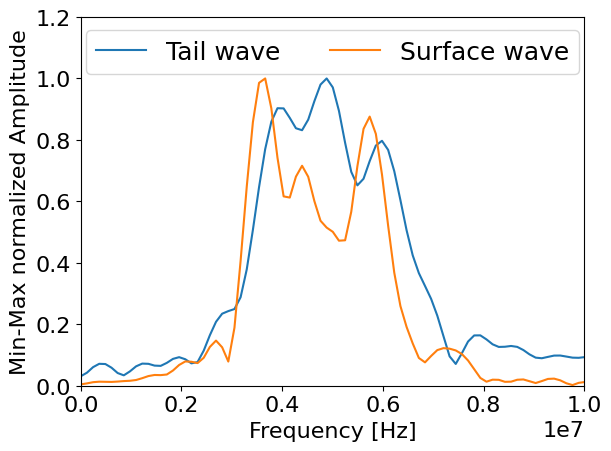

In [20]:

yf_surface_2, freq_surface = sourse_new.make_fftdata(sourse_new.kiritori2(sourse_new.interpolate_sim_one(data2[-1, middle_150, :]), sourse_new.left, sourse_new.right), sourse_new.exp_dt)

plt.rcParams["font.size"] = 16
plt.plot(freq[0], yf2_20[2]/yf2_20[2].max(), label="Tail wave")
plt.plot(freq_surface, yf_surface_2/yf_surface_2.max(), label="Surface wave")

plt.xlim(0, 10000000)
plt.ylim(0, 1.2)
plt.ylabel("Min-Max normalized Amplitude")
plt.xlabel("Frequency [Hz]")
plt.tight_layout()
plt.legend(loc='upper center', ncol=2, fontsize=18)
plt.savefig(r"C:\Users\manat\project2\drawing\sice\Figure9b.eps", format="eps", dpi=300)
plt.show()

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\125_2\scope_5b3_10.csv
importing : C:\Users\manat\project2\experience_new\125_2\scope_5b3_11.csv
importing : C:\Users\manat\project2\experience_new\125_2\scope_5b3_12.csv
importing : C:\Users\manat\project2\experience_new\125_2\scope_5b3_1

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


importing : C:\Users\manat\project2\experience_new\125_23\scope_5b1_35.csv
importing : C:\Users\manat\project2\experience_new\125_23\scope_5b1_36.csv
importing : C:\Users\manat\project2\experience_new\125_23\scope_5b1_37.csv
importing : C:\Users\manat\project2\experience_new\125_23\scope_5b1_38.csv
importing : C:\Users\manat\project2\experience_new\125_23\scope_5b1_39.csv


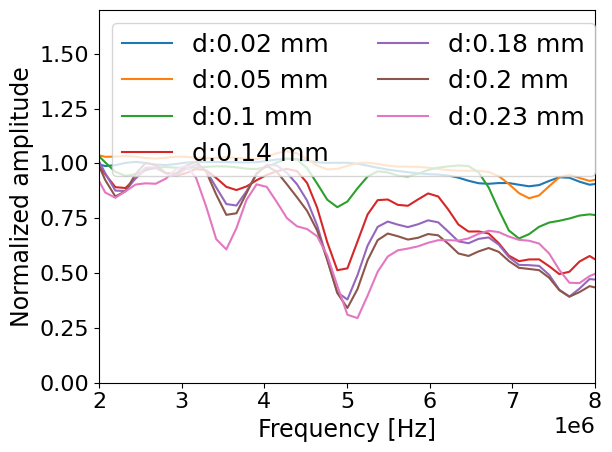

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\150_3\scope_5b5_150.csv
importing : C:\Users\manat\project2\experience_new\150_3\scope_5b5_151.csv
importing : C:\Users\manat\project2\experience_new\150_3\scope_5b5_152.csv
importing : C:\Users\manat\project2\experience_new\150_3\scope_5b

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_92.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_93.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_94.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_95.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_96.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_97.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_98.csv
importing : C:\Users\manat\project2\experience_new\150_20\scope_5b3_99.csv


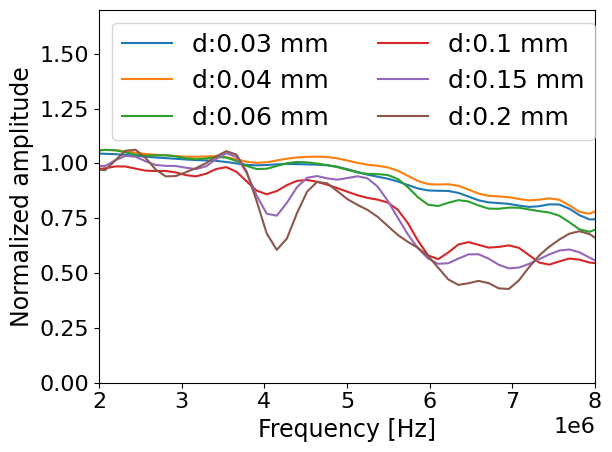

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\175_3\scope_5b5_180.csv
importing : C:\Users\manat\project2\experience_new\175_3\scope_5b5_181.csv
importing : C:\Users\manat\project2\experience_new\175_3\scope_5b5_182.csv
importing : C:\Users\manat\project2\experience_new\175_3\scope_5b

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


importing : C:\Users\manat\project2\experience_new\175_21\scope_5b3_120.csv
importing : C:\Users\manat\project2\experience_new\175_21\scope_5b3_121.csv
importing : C:\Users\manat\project2\experience_new\175_21\scope_5b3_122.csv
importing : C:\Users\manat\project2\experience_new\175_21\scope_5b3_123.csv
importing : C:\Users\manat\project2\experience_new\175_21\scope_5b3_124.csv
importing : C:\Users\manat\project2\experience_new\175_21\scope_5b3_125.csv
importing : C:\Users\manat\project2\experience_new\175_21\scope_5b3_126.csv
importing : C:\Users\manat\project2\experience_new\175_21\scope_5b3_127.csv
importing : C:\Users\manat\project2\experience_new\175_21\scope_5b3_128.csv
importing : C:\Users\manat\project2\experience_new\175_21\scope_5b3_129.csv


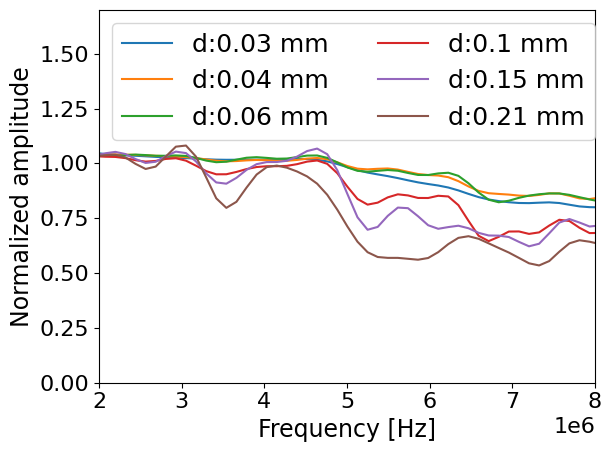

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\200_2\scope_5b3_40.csv
importing : C:\Users\manat\project2\experience_new\200_2\scope_5b3_41.csv
importing : C:\Users\manat\project2\experience_new\200_2\scope_5b3_42.csv
importing : C:\Users\manat\project2\experience_new\200_2\scope_5b3_4

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


importing : C:\Users\manat\project2\experience_new\200_28\scope_5b1_87.csv
importing : C:\Users\manat\project2\experience_new\200_28\scope_5b1_88.csv
importing : C:\Users\manat\project2\experience_new\200_28\scope_5b1_89.csv


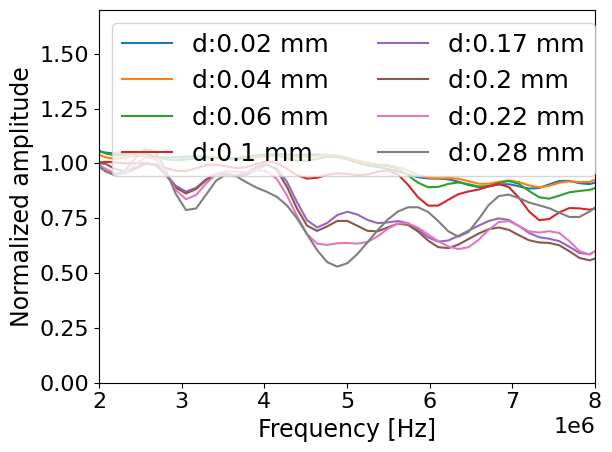

In [21]:
sourse_new.select_pitch_and_image_exp(125, [2, 5, 10, 14, 18, 20, 23])
sourse_new.select_pitch_and_image_exp(150, [3, 4, 6, 10, 15, 20])
sourse_new.select_pitch_and_image_exp(175, [3, 4, 6, 10, 15, 21])
sourse_new.select_pitch_and_image_exp(200, [2, 4, 6, 10, 17, 20, 22, 28])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


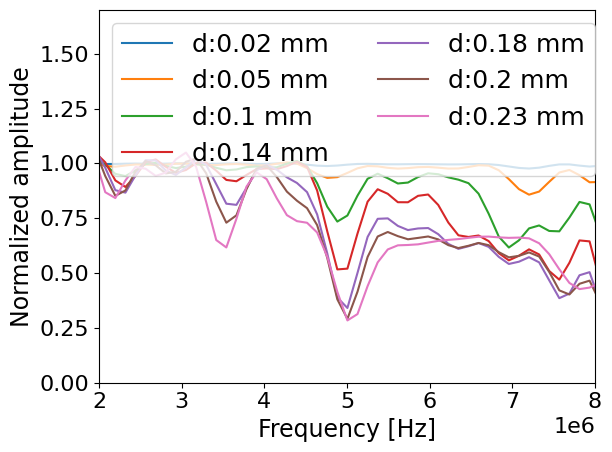

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


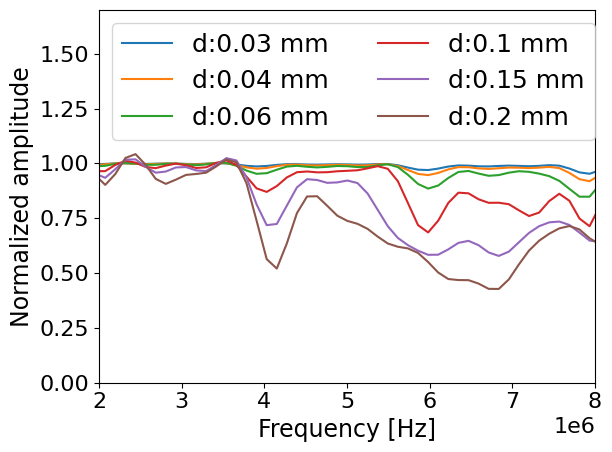

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


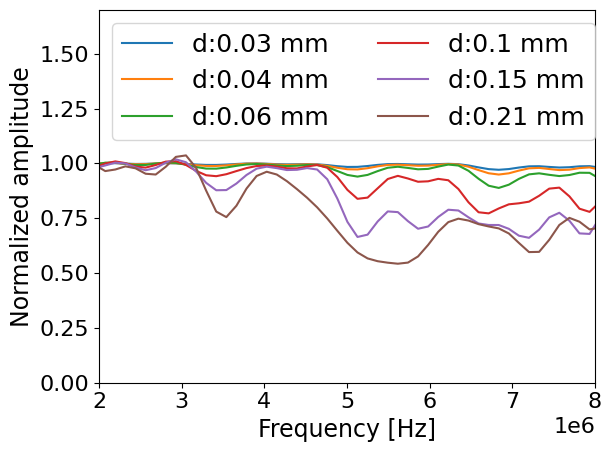

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


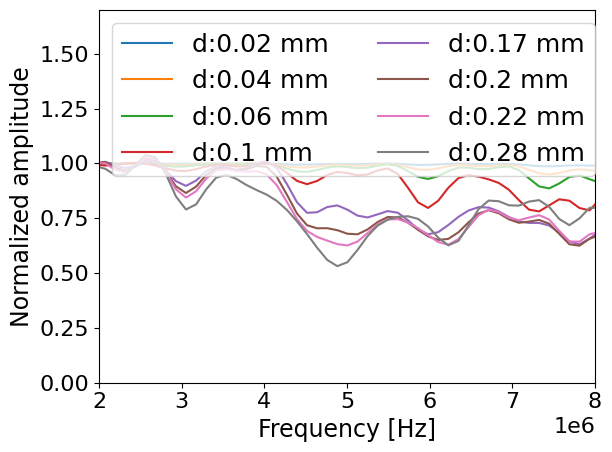

In [22]:
sourse_new.select_pitch_and_image(125, [2, 5, 10, 14, 18, 20, 23])
sourse_new.select_pitch_and_image(150, [3, 4, 6, 10, 15, 20])
sourse_new.select_pitch_and_image(175, [3, 4, 6, 10, 15, 21])
sourse_new.select_pitch_and_image(200, [2, 4, 6, 10, 17, 20, 22, 28])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


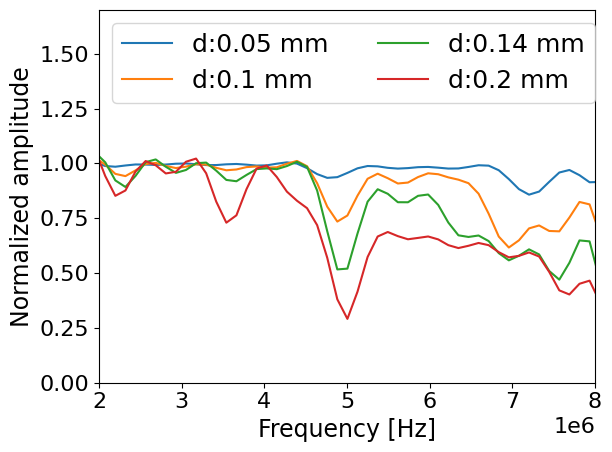

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


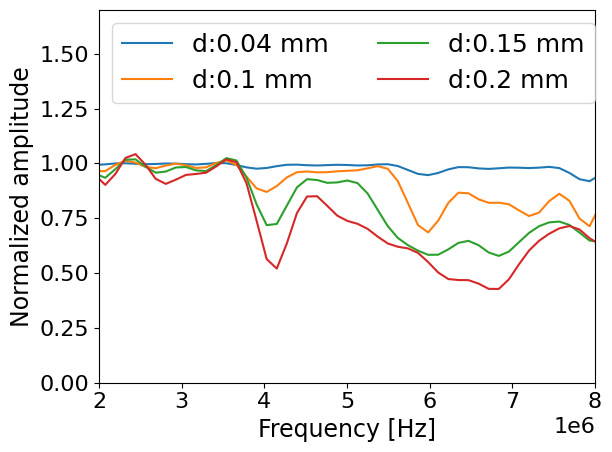

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


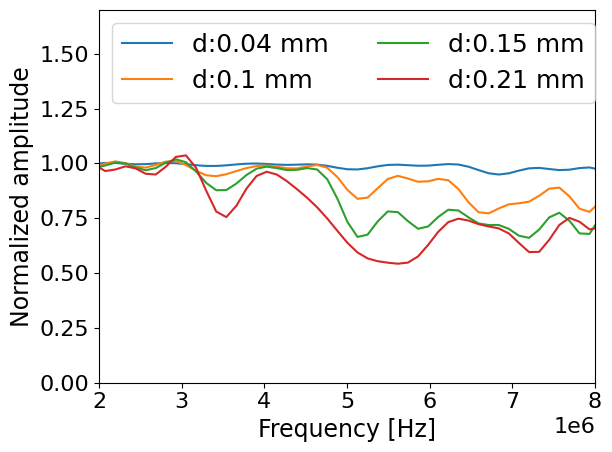

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


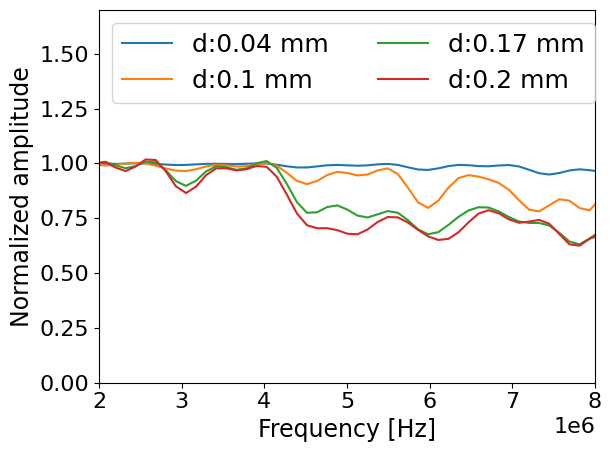

In [23]:
sourse_new.select_pitch_and_image(125, [5, 10, 14, 20])
sourse_new.select_pitch_and_image(150, [4, 10, 15, 20])
sourse_new.select_pitch_and_image(175, [4, 10, 15, 21])
sourse_new.select_pitch_and_image(200, [4, 10, 17, 20])

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\125_5\scope_5b3_30.csv
importing : C:\Users\manat\project2\experience_new\125_5\scope_5b3_31.csv
importing : C:\Users\manat\project2\experience_new\125_5\scope_5b3_32.csv
importing : C:\Users\manat\project2\experience_new\125_5\scope_5b3_3

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


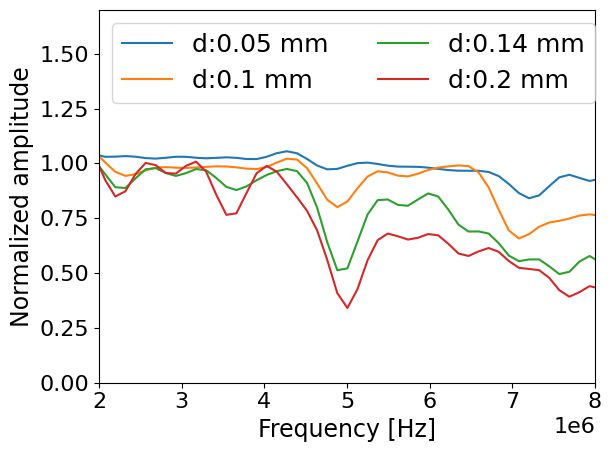

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\150_4\scope_5b5_160.csv
importing : C:\Users\manat\project2\experience_new\150_4\scope_5b5_161.csv
importing : C:\Users\manat\project2\experience_new\150_4\scope_5b5_162.csv
importing : C:\Users\manat\project2\experience_new\150_4\scope_5b

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


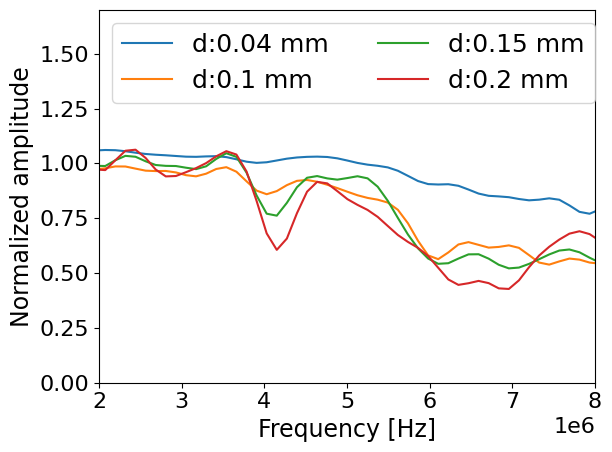

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\175_4\scope_5b5_190.csv
importing : C:\Users\manat\project2\experience_new\175_4\scope_5b5_191.csv
importing : C:\Users\manat\project2\experience_new\175_4\scope_5b5_192.csv
importing : C:\Users\manat\project2\experience_new\175_4\scope_5b

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


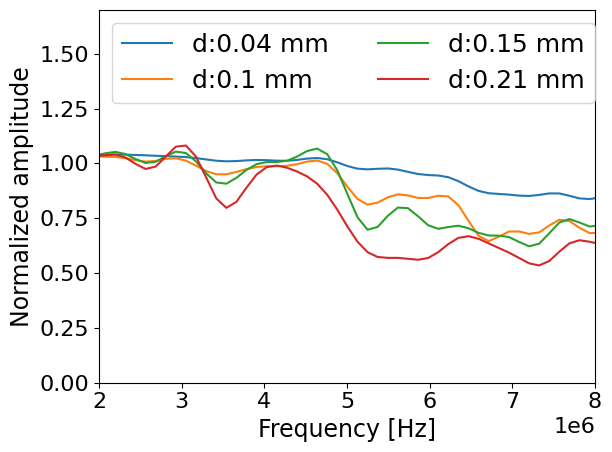

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\200_4\scope_5b3_50.csv
importing : C:\Users\manat\project2\experience_new\200_4\scope_5b3_51.csv
importing : C:\Users\manat\project2\experience_new\200_4\scope_5b3_52.csv
importing : C:\Users\manat\project2\experience_new\200_4\scope_5b3_5

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


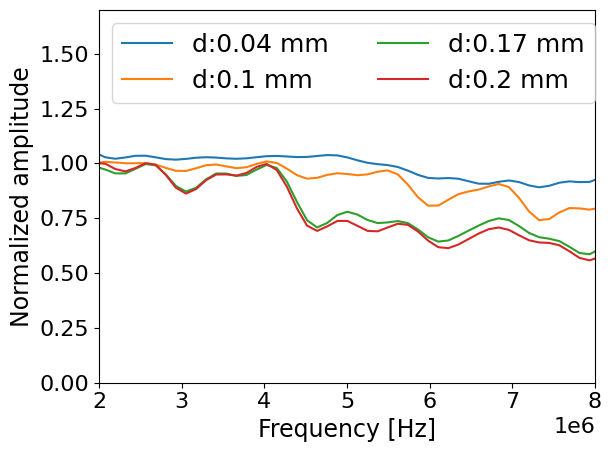

In [24]:
sourse_new.select_pitch_and_image_exp(125, [5, 10, 14, 20])
sourse_new.select_pitch_and_image_exp(150, [4, 10, 15, 20])
sourse_new.select_pitch_and_image_exp(175, [4, 10, 15, 21])
sourse_new.select_pitch_and_image_exp(200, [4, 10, 17, 20])

In [28]:
depth_list = [0, 40, 100, 150, 200]
surface_wave = np.zeros((6, 4096))
for i in range(len(depth_list)):
    surface_wave[i] = sourse_new.interpolate_sim_one(np.load(fr"C:\Users\manat\project2\surface_wave_2d\T3\T3_series_middle_point_pitch_150_depth{depth_list[i]}.npy"))[982:982+4096]
    surface_wave[i] = -surface_wave[i]

In [31]:
exp_wave = np.zeros((6, 20000))
for i in range(len(depth_list)):
    if i == 0:
        exp_wave[i] = sourse_new.import_data(0,0)[0]
    else:
        exp_wave[i] = sourse_new.import_data(150, int(depth_list[i]/10))[0]

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\150_4\scope_5b5_160.csv
importing : C:\Users\manat\project2\experience_new\150_4\scope_5b5_161.csv
importing : C:\Users\manat\project2\experience_new\150_4\scope_5b5_162.csv
importing : C:\Users\manat\project2\experience_new\150_4\scope_5b

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


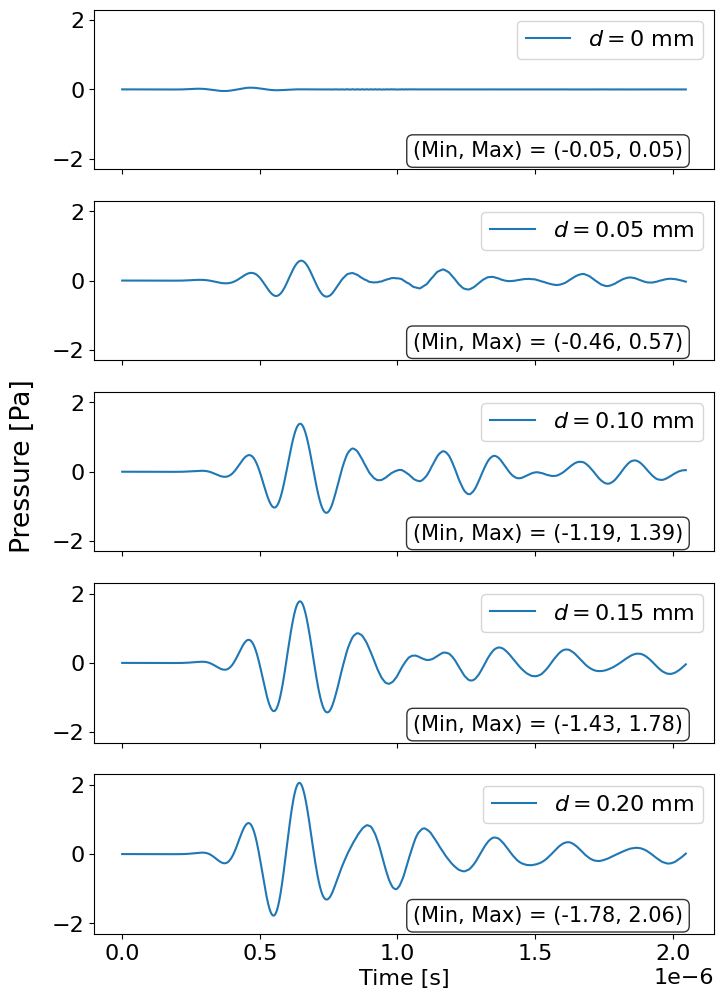

In [29]:
plt.rcParams["font.size"] = 16
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(8, 12))
time = np.arange(0, 4096*sourse_new.exp_dt, sourse_new.exp_dt)
labels = ["$d=0$ mm","$d=0.05$ mm","$d=0.10$ mm","$d=0.15$ mm","$d=0.20$ mm"]

for i in range(5):
    # 最大値と最小値を計算
    min_val = np.min(surface_wave[i])
    max_val = np.max(surface_wave[i])
    axes[i].plot(time, surface_wave[i], label=labels[i])
    axes[i].legend()
    axes[i].set_ylim(-2.3, 2.3)
    # 右下に最大値と最小値を表示
    axes[i].text(0.95, 0.05, f'(Min, Max) = ({min_val:.2f}, {max_val:.2f})', 
                 transform=axes[i].transAxes, 
                 verticalalignment='bottom', 
                 horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                 fontsize=15)



plt.xlabel("Time [s]")
fig.supylabel("Pressure [Pa]")
plt.savefig(r"C:\Users\manat\project2\drawing\sice\Figure10b.eps", format="eps")

# グラフを表示
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


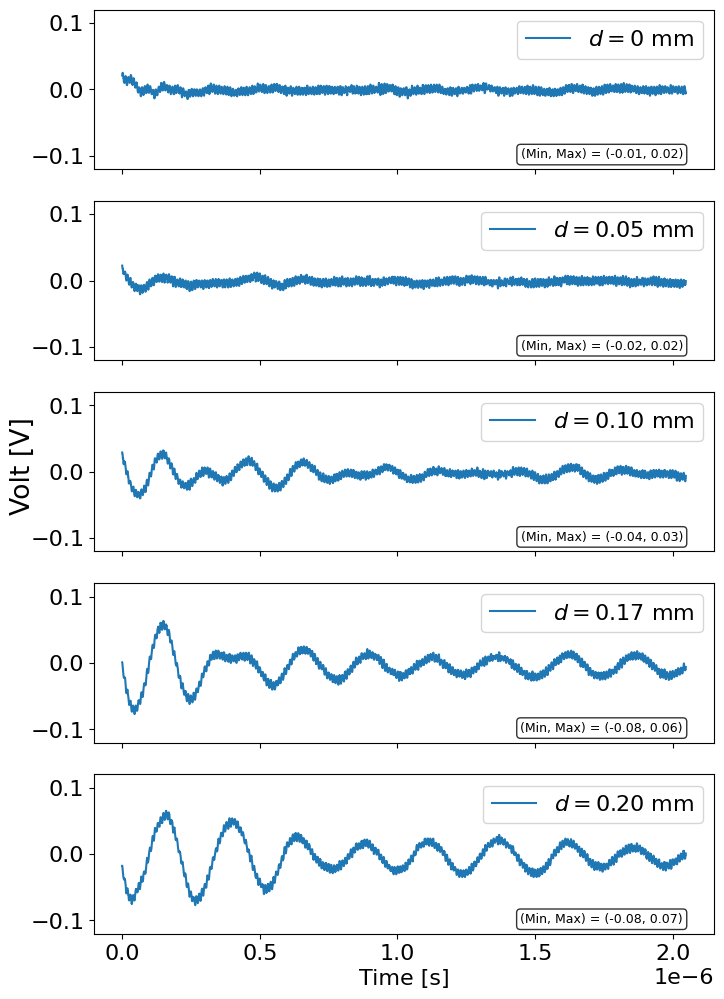

In [32]:
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(8, 12))
time_exp = np.arange(0, len(exp_wave[0][1800+sourse_new.left:4096+1800+sourse_new.left])*sourse_new.exp_dt, sourse_new.exp_dt)
labels = ["$d=0$ mm","$d=0.05$ mm","$d=0.10$ mm","$d=0.17$ mm","$d=0.20$ mm"]

for i in range(5):
    # 最大値と最小値を計算
    min_val = np.min(exp_wave[i][1800+sourse_new.left:4096+1800+sourse_new.left])
    max_val = np.max(exp_wave[i][1800+sourse_new.left:4096+1800+sourse_new.left])
    axes[i].plot(time_exp, exp_wave[i][1800+sourse_new.left:4096+1800+sourse_new.left], label=labels[i])
    axes[i].legend()
    axes[i].set_ylim(-0.12, 0.12)
    # 右下に最大値と最小値を表示
    axes[i].text(0.95, 0.05, f'(Min, Max) = ({min_val:.2f}, {max_val:.2f})', 
                 transform=axes[i].transAxes, 
                 verticalalignment='bottom', 
                 horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                 fontsize=9)


plt.xlabel("Time [s]")
fig.supylabel("Volt [V]")

plt.savefig(r"C:\Users\manat\project2\drawing\sice\Figure10a.eps", format="eps")

# グラフを表示
plt.show()